In [3]:
"""
Bifurcation Detection — Regression Training Pipeline & Streaming Deployment
============================================================================

Model outputs TWO heads per window:
  • p_bifurc  : P(a bifurcation exists in this window)          — binary [0,1]
  • t_bifurc  : normalised timestep of bifurcation ∈ [0,1]      — regression
                (only meaningful / penalised when p_bifurc > 0)

Why two heads?
  Null windows have no meaningful regression target.  Penalising the timestep
  head on null samples would force the network to predict an arbitrary number,
  corrupting the gradient signal.  Instead the regression loss is gated by
  whether the window actually contains a bifurcation.

Normalised timestep convention
  t_norm = (bifurcation_absolute_timestep − window_start) / window_length
  So t_norm=0.0 → bifurcation at the very start of the window
     t_norm=1.0 → bifurcation at the very end

Streaming deployment
  A rolling window strides across incoming data. Each stride produces:
    • updated p_bifurc estimate
    • predicted absolute timestep of the bifurcation
  An alert fires when p_bifurc passes a configurable threshold, with
  hysteresis to avoid duplicate alerts.
"""

import numpy as np
import torch
from torch.utils.data import DataLoader

from bi_plot import plot_recordings
from bi_data_sim import make_synthetic_recordings
from bi_data_struct import recording_level_split, BifurcationWindowDataset
from bi_model import BifurcationRegressor, train,collate_nan_safe, evaluate, GatedBifurcationLoss
from bi_stream import StreamingBifurcationDetector

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ── 1. Generate recordings and split by recording ─────────────────────
print("── Generating synthetic recordings ──")
all_recordings = make_synthetic_recordings(
    n_null=1000, n_positive=1000, num_params=4, depth=75, time_len=1048,seed=np.random.randint(1e6,size=1)
)
train_recs, val_recs, test_recs = recording_level_split(all_recordings)
print(f"  Train recordings: {len(train_recs)}  Val: {len(val_recs)}  Test: {len(test_recs)}\n")

Device: cuda

── Generating synthetic recordings ──
  Train recordings: 1400  Val: 300  Test: 300



In [5]:
# ── 2. Build window datasets ──────────────────────────────────────────
print("── Building window datasets ──")
WINDOW = 64
STRIDE = 16

train_ds = BifurcationWindowDataset(train_recs, window_len=WINDOW, stride=STRIDE, precursor_steps=64)
val_ds   = BifurcationWindowDataset(val_recs,   window_len=WINDOW, stride=STRIDE)
test_ds  = BifurcationWindowDataset(test_recs,  window_len=WINDOW, stride=STRIDE)

── Building window datasets ──
  Dataset: 86800 windows  (5576 positive = 6.4%)
  Dataset: 18600 windows  (580 positive = 3.1%)
  Dataset: 18600 windows  (632 positive = 3.4%)


In [6]:
# ── 3. Build and train model ──────────────────────────────────────────
print("── Training ──")
model = BifurcationRegressor(num_params=4).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {total_params:,}\n")

model = train(
    model, train_ds, val_ds, device,
    epochs=50,       # increase for real training
    batch_size=64,
    patience=10,
    save_path=None,  # set a path to save checkpoints
)

── Training ──
  Trainable parameters: 5,058,626

Epoch 001/50  | train loss=0.0805  det=0.0253  reg=0.0276  acc=0.956  t_mae=0.3194  || val loss=0.0128  det=0.0122  acc=0.997  t_mae=0.0278
Epoch 002/50  | train loss=0.0734  det=0.0241  reg=0.0247  acc=0.960  t_mae=0.2890  || val loss=0.0094  det=0.0091  acc=0.998  t_mae=0.0201
Epoch 003/50  | train loss=0.0730  det=0.0244  reg=0.0243  acc=0.960  t_mae=0.2824  || val loss=0.0097  det=0.0092  acc=0.998  t_mae=0.0287
Epoch 004/50  | train loss=0.0693  det=0.0231  reg=0.0231  acc=0.963  t_mae=0.2669  || val loss=0.0107  det=0.0104  acc=0.997  t_mae=0.0187
Epoch 005/50  | train loss=0.0719  det=0.0241  reg=0.0239  acc=0.960  t_mae=0.2821  || val loss=0.0124  det=0.0113  acc=0.997  t_mae=0.0337
Epoch 006/50  | train loss=0.0701  det=0.0235  reg=0.0233  acc=0.962  t_mae=0.2708  || val loss=0.0096  det=0.0086  acc=0.995  t_mae=0.0361
Epoch 007/50  | train loss=0.0695  det=0.0235  reg=0.0230  acc=0.962  t_mae=0.2710  || val loss=0.0089  det=0.

In [7]:
# ── 4. Test set evaluation ────────────────────────────────────────────
print("\n── Test set evaluation ──")
test_loader = DataLoader(
    test_ds, batch_size=64, collate_fn=collate_nan_safe
)
criterion = GatedBifurcationLoss()
test_metrics = evaluate(model, test_loader, criterion, device)
print(
    f"  test loss={test_metrics['loss']:.4f}  "
    f"det_acc={test_metrics['det_acc']:.3f}  "
    f"timing_mae={test_metrics['timing_mae']:.4f} (normalised)"
)
print(
    f"  timing_mae in timesteps ≈ {test_metrics['timing_mae'] * WINDOW:.1f} / {WINDOW}"
)


── Test set evaluation ──
  test loss=0.0120  det_acc=0.996  timing_mae=0.0342 (normalised)
  timing_mae in timesteps ≈ 2.2 / 64


In [9]:
# ── 5. Streaming demo ─────────────────────────────────────────────────
print("\n── Streaming demo ──")
detector = StreamingBifurcationDetector(
    model, window_len=WINDOW, stride=STRIDE,
    threshold=0.55, cooldown_steps=32, ema_alpha=0.4, device=device,
)

# Pick a positive test recording and stream it in stride-sized chunks
pos_recs = [r for r in test_recs if r.is_positive]
if pos_recs:
    rec = pos_recs[0]
    print(f"  Streaming recording '{rec.recording_id}'  "
          f"(true bifurcation at t={rec.bifurcation_t}, "
          f"total T={rec.time_len})")

    for t in range(0, rec.time_len, STRIDE):
        chunk = rec.data[:, :, t : t + STRIDE]
        if chunk.shape[2] == 0:
            print("warning chunk wrong shape!")
            break
        alerts = detector.push(chunk)
        for alert in alerts:
            lead = alert.steps_until_bifurc
            lead_str = f"{lead:+d} steps" if lead >= 0 else f"{abs(lead)} steps AFTER"
            print(
                f"  🚨 ALERT  t={alert.absolute_timestep:4d}  "
                f"p={alert.p_bifurcation:.3f}  "
                f"predicted_t={alert.predicted_bifurc_t}  "
                f"lead={lead_str}"
            )
else:
    print("  (No positive recordings in test split — increase n_positive or use a fixed seed)")

print(f"Highlight: {rec.recording_id}")
print(f"  Actual bifurcation    : t={rec.bifurcation_t}")
print(f"  Prediction bifurcation  : t={alert.predicted_bifurc_t}")


── Streaming demo ──
  Streaming recording 'pos_0631'  (true bifurcation at t=493, total T=1048)
  🚨 ALERT  t= 512  p=0.586  predicted_t=492  lead=20 steps AFTER
Highlight: pos_0631
  Actual bifurcation    : t=493
  Prediction bifurcation  : t=492


  Saved → bifurcation_plot.png


(<Figure size 1400x1120 with 4 Axes>,
 array([<Axes: ylabel='Parameter 1'>, <Axes: ylabel='Parameter 2'>,
        <Axes: ylabel='Parameter 3'>,
        <Axes: xlabel='Timestep', ylabel='Parameter 4'>], dtype=object))

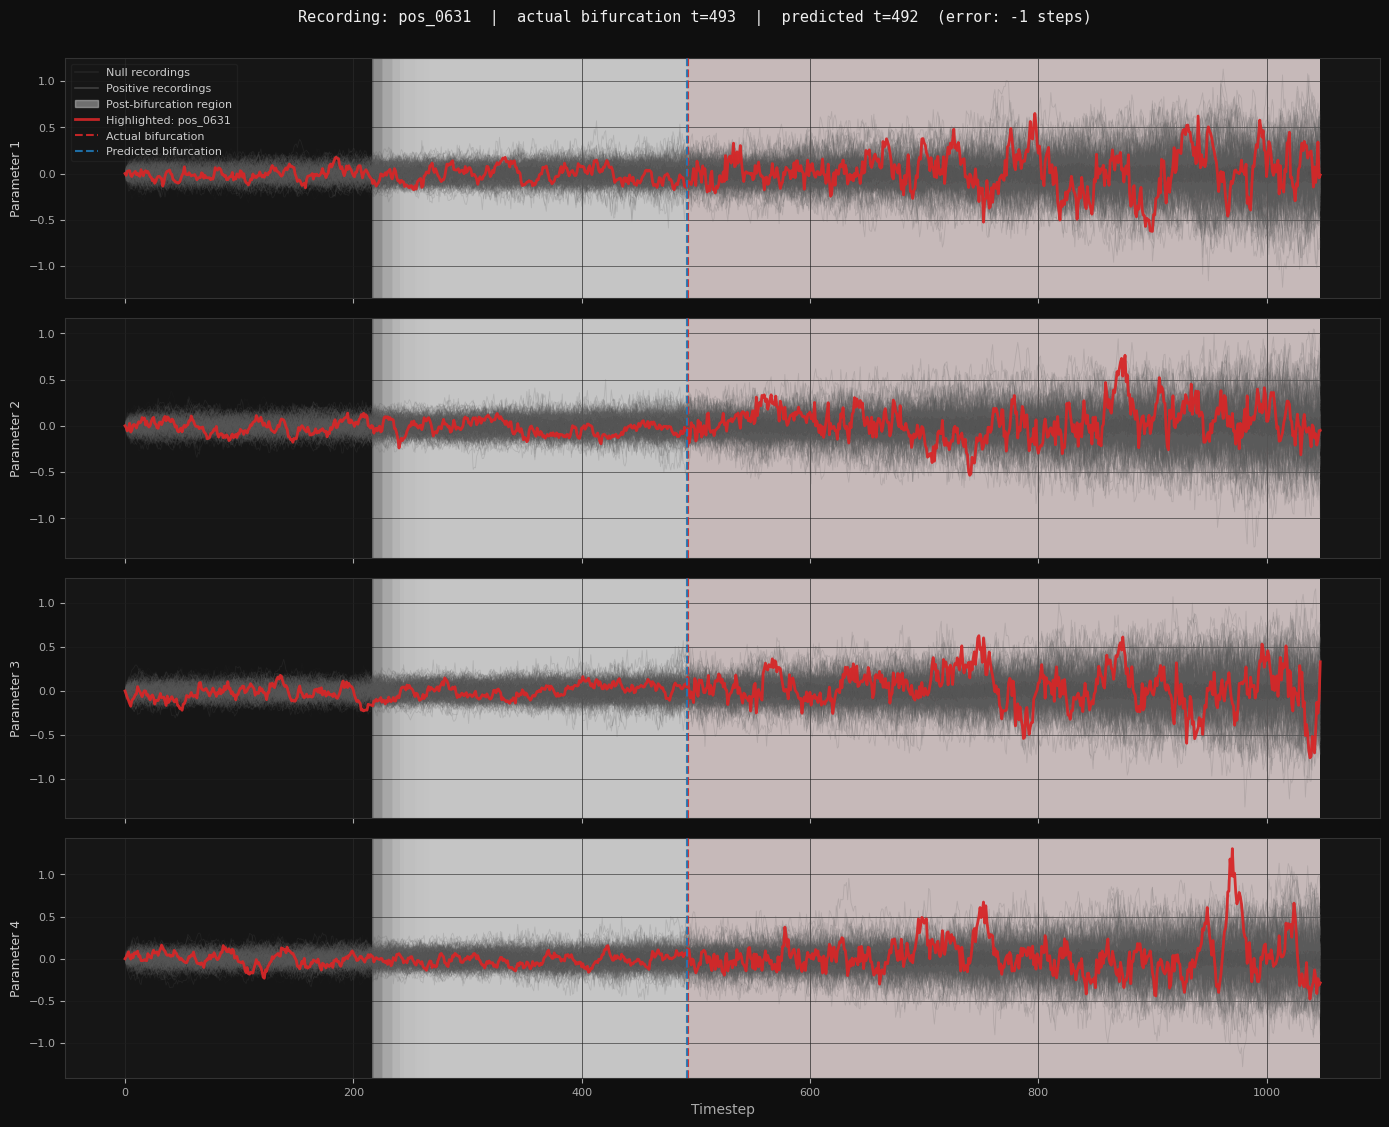

In [10]:
# ── 6. Plot recordings ─────────────────────────────────────────────────
plot_recordings(
    recordings=test_recs,
    highlight=rec,
    predicted_t=alert.predicted_bifurc_t,
    depth_summary="mean",
    param_names=["Parameter 1", "Parameter 2", "Parameter 3", "Parameter 4"],
    save_path="bifurcation_plot.png",
)

